# Confronto ResNet-18 vs MobileNetV2 — BloodMNIST

Questo notebook confronta i due modelli addestrati su BloodMNIST lungo cinque dimensioni:
1. Architettura e complessità
2. Accuratezza su dati puliti
3. Robustezza avversariale (FGSM e PGD)
4. Classi critiche per la β-talassemia
5. Spiegabilità (Grad-CAM)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import medmnist
from medmnist import BloodMNIST

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, f1_score, accuracy_score)
from sklearn.preprocessing import label_binarize


# ── Cartelle di output (relative alla cartella Notebook) ──────────────────────
MODELS_DIR = '../Modelli'
IMAGES_DIR = '../Immagini'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)


torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

NUM_CLASSES = 8
CLASSES = [
    'Basofilo', 'Eosinofilo', 'Eritroblasto',
    'Gran. Immaturo', 'Linfocito', 'Monocito',
    'Neutrofilo', 'Piastrina'
]

# Classi β-talassemia (diverse tra i due modelli)
THAL_RN  = [2, 3, 7]   # ResNet-18:    Eritroblasto, Gran.Immaturo, Piastrina
THAL_MN  = [2, 3, 7]   # MobileNetV2:  Eritroblasto, Gran.Immaturo, Piastrina
THAL_ALL = [2, 3, 7]   # identici — confronto diretto possibile

# Path pesi salvati — modifica se i file sono in cartella diversa
PATH_RN = os.path.join(MODELS_DIR, 'gs_best.pth')
PATH_MN = os.path.join(MODELS_DIR, 'best_mobilenetv2.pth')

print(f'Classi: {CLASSES}')
print(f'β-tal (entrambi):  {[CLASSES[i] for i in THAL_ALL]}')

Device: cuda
Classi: ['Basofilo', 'Eosinofilo', 'Eritroblasto', 'Gran. Immaturo', 'Linfocito', 'Monocito', 'Neutrofilo', 'Piastrina']
β-tal (entrambi):  ['Eritroblasto', 'Gran. Immaturo', 'Piastrina']


---
## 1. Caricamento Modelli

In [2]:
# ── Definizione architetture ──────────────────────────────────────────────────
def build_resnet18(num_classes=8, dropout=0.3):
    m = models.resnet18(weights=None)
    m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.fc.in_features, num_classes))
    return m

def build_mobilenetv2(num_classes=8, dropout=0.3):
    m = models.mobilenet_v2(weights=None)
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(1280, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout * 0.67),
        nn.Linear(256, num_classes)
    )
    return m

# ── Caricamento pesi ──────────────────────────────────────────────────────────
resnet   = build_resnet18().to(device)
mobilenet = build_mobilenetv2().to(device)

resnet.load_state_dict(torch.load(PATH_RN, map_location=device, weights_only=True))
mobilenet.load_state_dict(torch.load(PATH_MN, map_location=device, weights_only=True))
resnet.eval()
mobilenet.eval()

print('✓ ResNet-18    caricato da', PATH_RN)
print('✓ MobileNetV2  caricato da', PATH_MN)

RuntimeError: Error(s) in loading state_dict for ResNet:
	Missing key(s) in state_dict: "conv1.weight", "bn1.weight", "bn1.bias", "bn1.running_mean", "bn1.running_var", "layer1.0.conv1.weight", "layer1.0.bn1.weight", "layer1.0.bn1.bias", "layer1.0.bn1.running_mean", "layer1.0.bn1.running_var", "layer1.0.conv2.weight", "layer1.0.bn2.weight", "layer1.0.bn2.bias", "layer1.0.bn2.running_mean", "layer1.0.bn2.running_var", "layer1.1.conv1.weight", "layer1.1.bn1.weight", "layer1.1.bn1.bias", "layer1.1.bn1.running_mean", "layer1.1.bn1.running_var", "layer1.1.conv2.weight", "layer1.1.bn2.weight", "layer1.1.bn2.bias", "layer1.1.bn2.running_mean", "layer1.1.bn2.running_var", "layer2.0.conv1.weight", "layer2.0.bn1.weight", "layer2.0.bn1.bias", "layer2.0.bn1.running_mean", "layer2.0.bn1.running_var", "layer2.0.conv2.weight", "layer2.0.bn2.weight", "layer2.0.bn2.bias", "layer2.0.bn2.running_mean", "layer2.0.bn2.running_var", "layer2.0.downsample.0.weight", "layer2.0.downsample.1.weight", "layer2.0.d

In [ ]:
# ── Trasformazioni (dimensioni diverse per i due modelli) ─────────────────────
IMG_RN = 224   # ResNet-18
IMG_MN = 224   # MobileNetV2

_norm = dict(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def make_transform(size=224):
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(**_norm)
    ])

def make_loader(size, batch_size=64):
    ds = BloodMNIST(split='test', transform=make_transform(size), download=True, size=224)
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)

test_loader_rn = make_loader(IMG_RN)
test_loader_mn = make_loader(IMG_MN)
test_dataset_rn = BloodMNIST(split='test', transform=make_transform(IMG_RN), download=True)
test_dataset_mn = BloodMNIST(split='test', transform=make_transform(IMG_MN), download=True)

print(f'Test set: {len(test_loader_rn.dataset)} campioni')
print(f'ResNet-18   input: {IMG_RN}×{IMG_RN}')
print(f'MobileNetV2 input: {IMG_MN}×{IMG_MN}')

Test set: 3421 campioni
ResNet-18   input: 224×224
MobileNetV2 input: 224×224


---
## 2. Architettura e Complessità

Metrica                           ResNet-18    MobileNetV2
──────────────────────────────────────────────────────────
Parametri totali                 11,180,616      2,553,864
Parametri trainabili             11,180,616      2,553,864
Dimensione pesi (MB)                   44.7           10.2
Input size (px)                         224            224
Inferenza (ms/batch)                  766.9          743.4


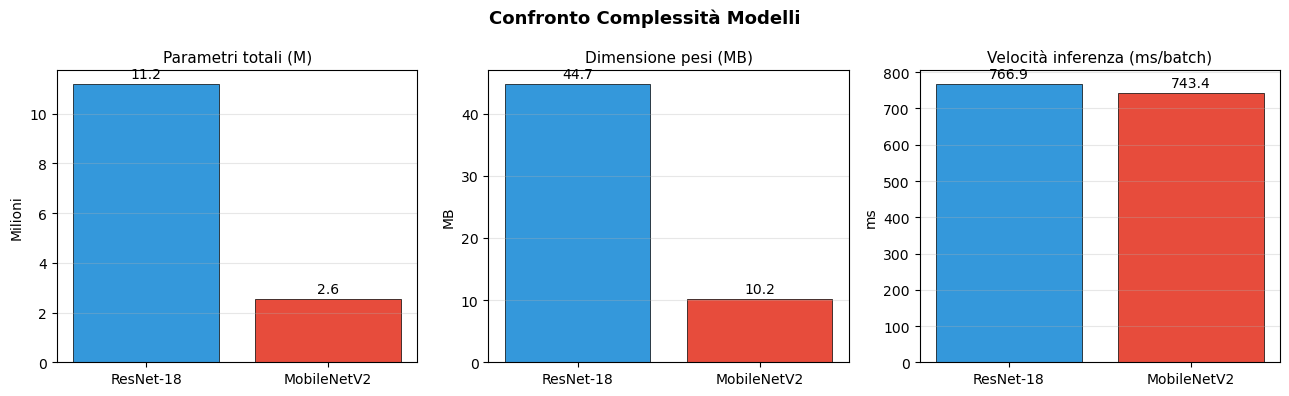

In [ ]:
# ── Parametri e velocità di inferenza ────────────────────────────────────────
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6

def inference_speed(model, loader, n_batches=20):
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs.to(device)
    # warmup
    with torch.no_grad():
        for _ in range(3): model(imgs)
    t0 = time.perf_counter()
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches: break
            model(imgs.to(device))
    return (time.perf_counter() - t0) / n_batches * 1000   # ms per batch

rn_total,  rn_train  = count_params(resnet)
mn_total,  mn_train  = count_params(mobilenet)
rn_size_mb  = model_size_mb(resnet)
mn_size_mb  = model_size_mb(mobilenet)
rn_speed    = inference_speed(resnet,   test_loader_rn)
mn_speed    = inference_speed(mobilenet, test_loader_mn)

print(f'{"Metrica":<28} {"ResNet-18":>14} {"MobileNetV2":>14}')
print('─' * 58)
print(f'{"Parametri totali":<28} {rn_total:>14,} {mn_total:>14,}')
print(f'{"Parametri trainabili":<28} {rn_train:>14,} {mn_train:>14,}')
print(f'{"Dimensione pesi (MB)":<28} {rn_size_mb:>14.1f} {mn_size_mb:>14.1f}')
print(f'{"Input size (px)":<28} {IMG_RN:>14} {IMG_MN:>14}')
print(f'{"Inferenza (ms/batch)":<28} {rn_speed:>14.1f} {mn_speed:>14.1f}')

# Barplot parametri
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
models_names = ['ResNet-18', 'MobileNetV2']
colors = ['#3498db', '#e74c3c']

axes[0].bar(models_names, [rn_total/1e6, mn_total/1e6], color=colors, edgecolor='black', lw=0.5)
axes[0].set_title('Parametri totali (M)', fontsize=11)
axes[0].set_ylabel('Milioni'); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models_names, [rn_size_mb, mn_size_mb], color=colors, edgecolor='black', lw=0.5)
axes[1].set_title('Dimensione pesi (MB)', fontsize=11)
axes[1].set_ylabel('MB'); axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models_names, [rn_speed, mn_speed], color=colors, edgecolor='black', lw=0.5)
axes[2].set_title('Velocità inferenza (ms/batch)', fontsize=11)
axes[2].set_ylabel('ms'); axes[2].grid(axis='y', alpha=0.3)

for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ax.get_ylim()[1]*0.01,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Confronto Complessità Modelli', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_complexity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Accuratezza su Dati Puliti

In [ ]:
# ── Predizioni su test set pulito ────────────────────────────────────────────
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.squeeze().numpy())
            all_probs.append(probs.cpu().numpy())
    return (np.array(all_preds), np.array(all_labels),
            np.concatenate(all_probs, axis=0))

rn_preds, rn_labels, rn_probs = get_predictions(resnet,   test_loader_rn)
mn_preds, mn_labels, mn_probs = get_predictions(mobilenet, test_loader_mn)

rn_acc = accuracy_score(rn_labels, rn_preds)
mn_acc = accuracy_score(mn_labels, mn_preds)

print(f'Accuratezza test — ResNet-18:   {rn_acc:.4%}')
print(f'Accuratezza test — MobileNetV2: {mn_acc:.4%}')
print(f'Δ (ResNet − MobileNet):         {(rn_acc - mn_acc):+.4%}')

Accuratezza test — ResNet-18:   98.3631%
Accuratezza test — MobileNetV2: 98.3046%
Δ (ResNet − MobileNet):         +0.0585%


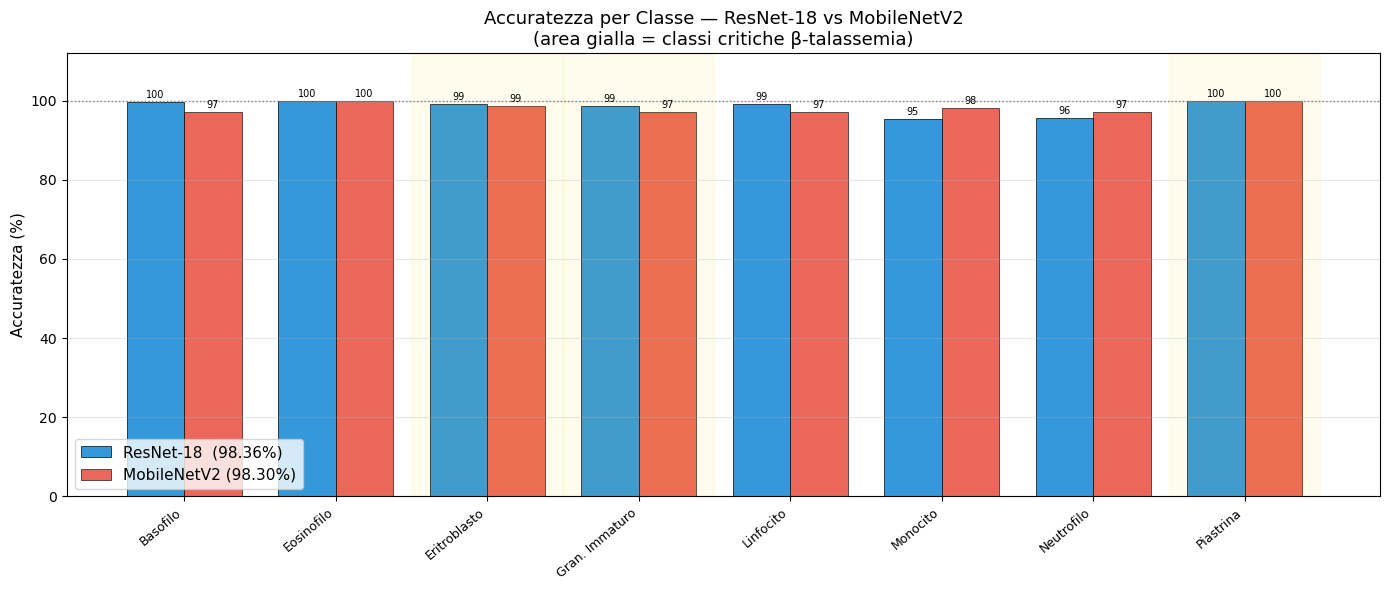

In [ ]:
# ── Accuratezza per classe ────────────────────────────────────────────────────
rn_class_acc = [accuracy_score(rn_labels[rn_labels==i], rn_preds[rn_labels==i])
                for i in range(NUM_CLASSES)]
mn_class_acc = [accuracy_score(mn_labels[mn_labels==i], mn_preds[mn_labels==i])
                for i in range(NUM_CLASSES)]

x = np.arange(NUM_CLASSES)
w = 0.38
fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - w/2, [a*100 for a in rn_class_acc], w,
               label=f'ResNet-18  ({rn_acc:.2%})', color='#3498db', edgecolor='black', lw=0.5)
bars2 = ax.bar(x + w/2, [a*100 for a in mn_class_acc], w,
               label=f'MobileNetV2 ({mn_acc:.2%})', color='#e74c3c', edgecolor='black', lw=0.5, alpha=0.85)

for idx in THAL_ALL:
    ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.07, color='gold')

ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Accuratezza (%)', fontsize=11)
ax.set_ylim(0, 112)
ax.set_title('Accuratezza per Classe — ResNet-18 vs MobileNetV2\n(area gialla = classi critiche β-talassemia)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.axhline(100, color='gray', ls=':', lw=1)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

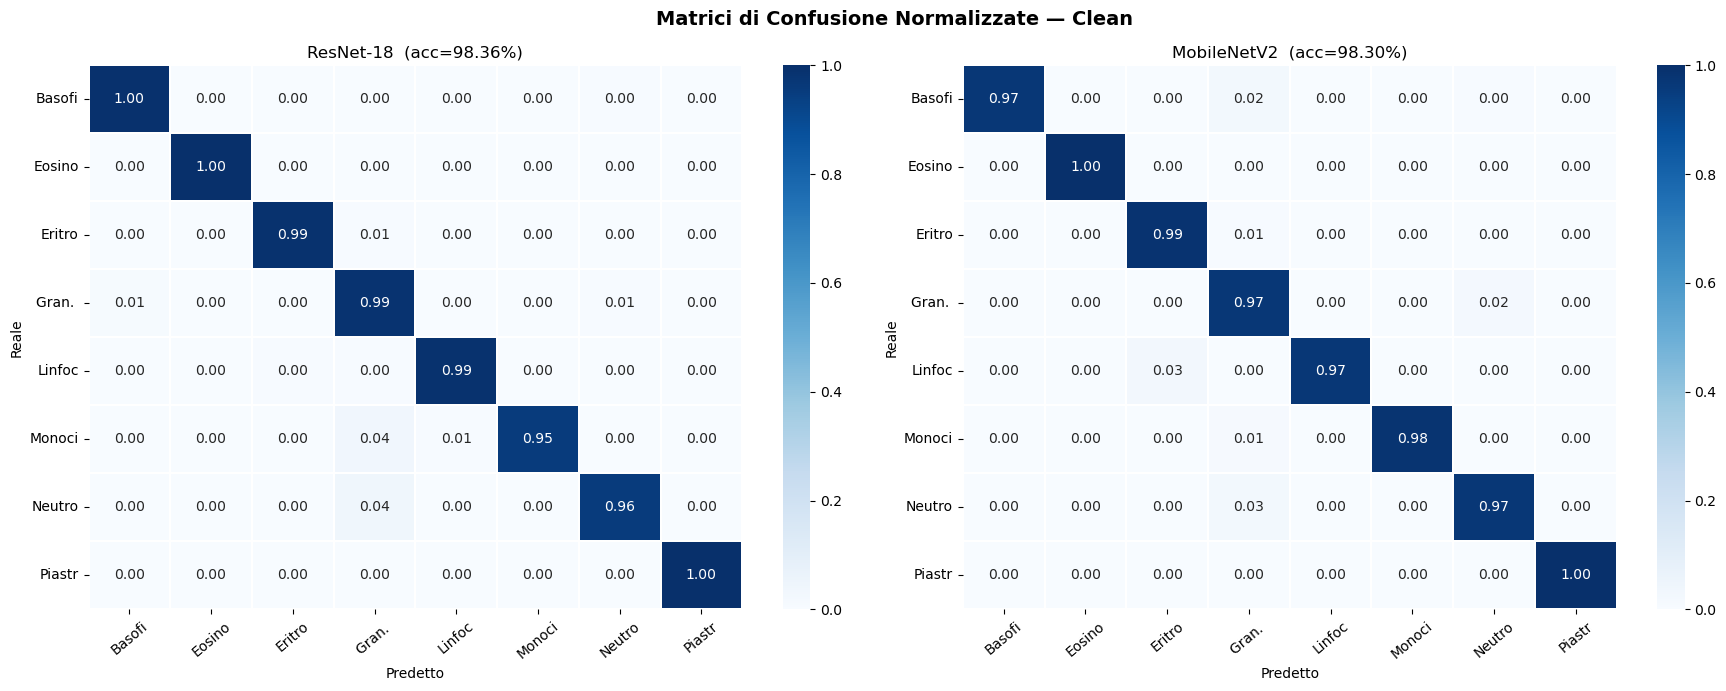

In [ ]:
# ── Matrici di confusione affiancate ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
short = [c[:6] for c in CLASSES]

for ax, preds, labels, title in [
    (axes[0], rn_preds,  rn_labels,  'ResNet-18'),
    (axes[1], mn_preds,  mn_labels,  'MobileNetV2')
]:
    cm = confusion_matrix(labels, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=short, yticklabels=short, linewidths=0.3,
                vmin=0, vmax=1)
    ax.set_title(f'{title}  (acc={accuracy_score(labels,preds):.2%})', fontsize=12)
    ax.set_xlabel('Predetto', fontsize=10)
    ax.set_ylabel('Reale',    fontsize=10)
    ax.tick_params(axis='x', rotation=40)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Matrici di Confusione Normalizzate — Clean', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

Classe                  ResNet-18  MobileNetV2        Δ
────────────────────────────────────────────────────────
Basofilo                   0.9858       0.9854  -0.0004
Eosinofilo                 0.9992       0.9992  +0.0000
Eritroblasto               0.9935       0.9793  -0.0143  ◀ β-tal
Gran. Immaturo             0.9589       0.9608  +0.0019  ◀ β-tal
Linfocito                  0.9918       0.9833  -0.0084
Monocito                   0.9748       0.9859  +0.0110
Neutrofilo                 0.9748       0.9751  +0.0004
Piastrina                  1.0000       1.0000  +0.0000  ◀ β-tal
────────────────────────────────────────────────────────
Macro-average              0.9848       0.9836  -0.0012


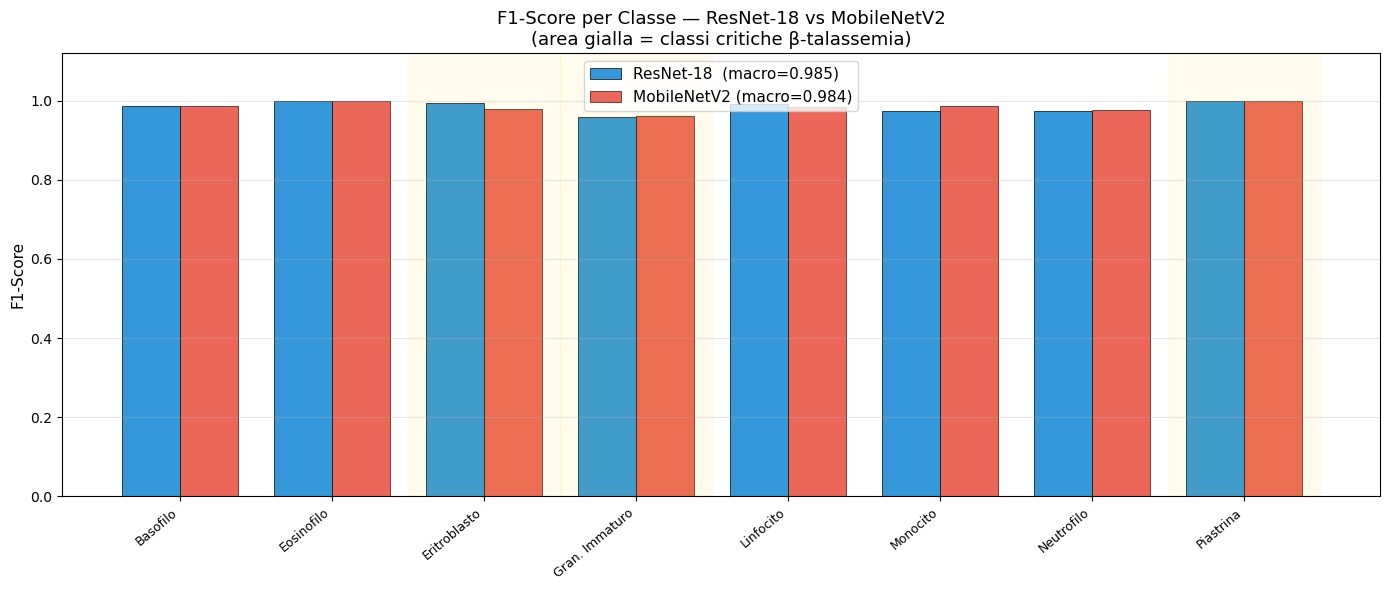

In [ ]:
# ── F1-Score per classe ───────────────────────────────────────────────────────
rn_f1 = f1_score(rn_labels, rn_preds, average=None)
mn_f1 = f1_score(mn_labels, mn_preds, average=None)
rn_macro = f1_score(rn_labels, rn_preds, average='macro')
mn_macro = f1_score(mn_labels, mn_preds, average='macro')

x = np.arange(NUM_CLASSES)
w = 0.38
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, rn_f1, w, label=f'ResNet-18  (macro={rn_macro:.3f})',
       color='#3498db', edgecolor='black', lw=0.5)
ax.bar(x + w/2, mn_f1, w, label=f'MobileNetV2 (macro={mn_macro:.3f})',
       color='#e74c3c', edgecolor='black', lw=0.5, alpha=0.85)

for idx in THAL_ALL:
    ax.axvspan(idx - 0.5, idx + 0.5, alpha=0.07, color='gold')

ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('F1-Score', fontsize=11); ax.set_ylim(0, 1.12)
ax.set_title('F1-Score per Classe — ResNet-18 vs MobileNetV2\n(area gialla = classi critiche β-talassemia)',
             fontsize=13)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

print(f'{"Classe":<22} {"ResNet-18":>10} {"MobileNetV2":>12} {"Δ":>8}')
print('─' * 56)
for i, cls in enumerate(CLASSES):
    mark = '  ◀ β-tal' if i in THAL_ALL else ''
    delta = mn_f1[i] - rn_f1[i]
    print(f'{cls:<22} {rn_f1[i]:>10.4f} {mn_f1[i]:>12.4f} {delta:>+8.4f}{mark}')
print('─' * 56)
print(f'{"Macro-average":<22} {rn_macro:>10.4f} {mn_macro:>12.4f} {mn_macro-rn_macro:>+8.4f}')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

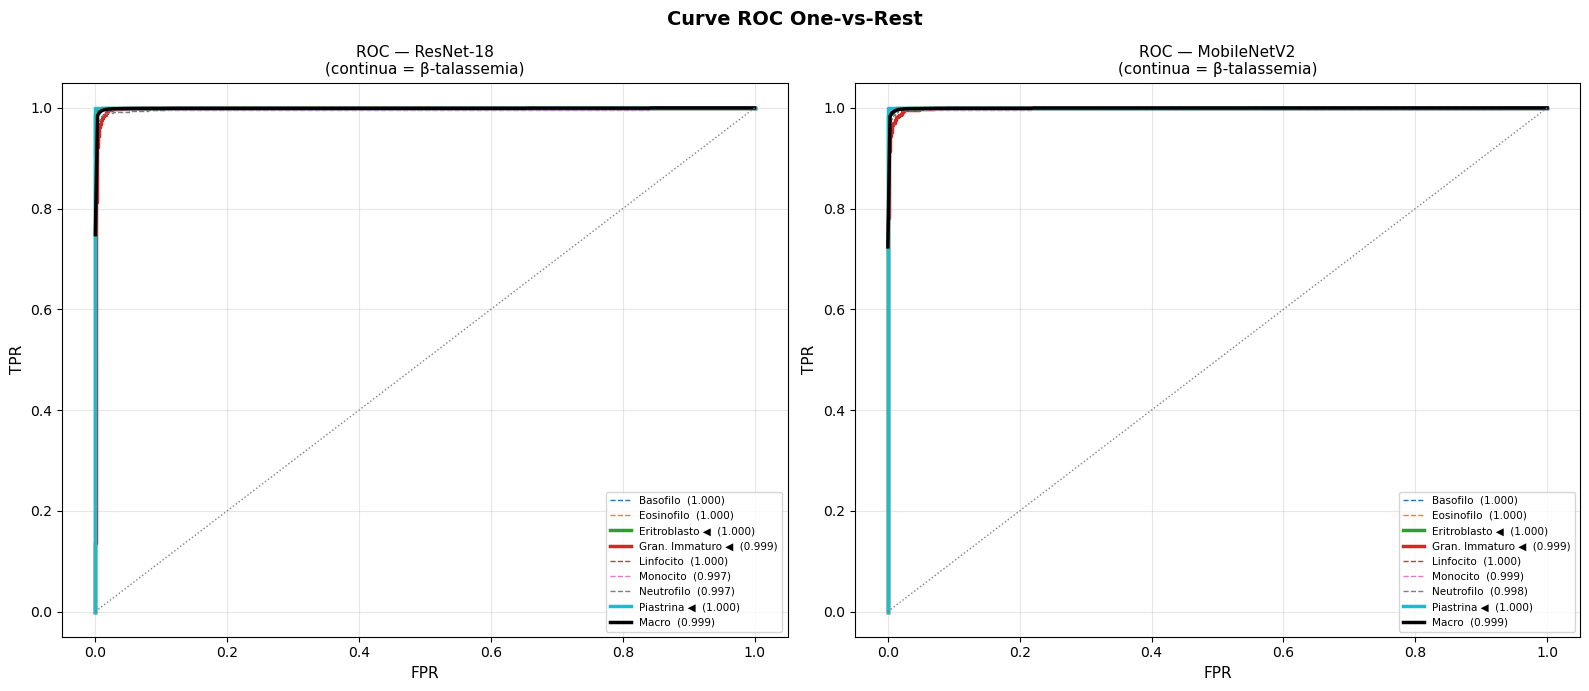

In [ ]:
# ── Curve ROC — entrambi i modelli sullo stesso plot ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, probs, labels, title, thal in [
    (axes[0], rn_probs, rn_labels, 'ResNet-18',    THAL_RN),
    (axes[1], mn_probs, mn_labels, 'MobileNetV2',  THAL_MN)
]:
    y_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    colors = plt.cm.tab10(np.linspace(0, 0.9, NUM_CLASSES))
    fpr_g = np.linspace(0, 1, 300); mean_tpr = np.zeros(300)

    for i, (cls, color) in enumerate(zip(CLASSES, colors)):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], probs[:, i])
        auc_i = auc(fpr_i, tpr_i)
        mean_tpr += np.interp(fpr_g, fpr_i, tpr_i)
        is_thal = i in thal
        ax.plot(fpr_i, tpr_i, color=color,
                lw=2.5 if is_thal else 1.0,
                ls='-'  if is_thal else '--',
                label=f'{cls}{" ◀" if is_thal else ""}  ({auc_i:.3f})')

    mean_tpr /= NUM_CLASSES
    ax.plot(fpr_g, mean_tpr, 'k-', lw=2.5, label=f'Macro  ({auc(fpr_g, mean_tpr):.3f})')
    ax.plot([0,1],[0,1], color='gray', lw=1, ls=':')
    ax.set_xlabel('FPR', fontsize=11); ax.set_ylabel('TPR', fontsize=11)
    ax.set_title(f'ROC — {title}\n(continua = β-talassemia)', fontsize=11)
    ax.legend(loc='lower right', fontsize=7.5); ax.grid(alpha=0.3)

plt.suptitle('Curve ROC One-vs-Rest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Robustezza Avversariale

In [ ]:
# ── Funzioni attacco FGSM e PGD ──────────────────────────────────────────────
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    labels = labels.reshape(-1).long().to(device)
    images.requires_grad_(True)
    loss = nn.CrossEntropyLoss()(model(images), labels)
    model.zero_grad(); loss.backward()
    return (images + epsilon * images.grad.sign()).detach()

def pgd_attack(model, images, labels, epsilon, alpha=0.01, num_steps=10):
    images = images.clone().detach().to(device)
    labels = labels.reshape(-1).long().to(device)
    adv = images + torch.empty_like(images).uniform_(-epsilon, epsilon)
    adv = adv.detach()
    for _ in range(num_steps):
        adv.requires_grad_(True)
        loss = nn.CrossEntropyLoss()(model(adv), labels)
        model.zero_grad(); loss.backward()
        adv = adv + alpha * adv.grad.sign()
        adv = (images + torch.clamp(adv - images, -epsilon, epsilon)).detach()
    return adv

def adversarial_accuracy(model, loader, attack_fn, epsilon, **kw):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.squeeze().long().to(device)
        adv    = attack_fn(model, imgs, labels, epsilon, **kw) if epsilon > 0 else imgs
        with torch.no_grad():
            preds = model(adv).argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total

print('✓ Funzioni attacco definite')

✓ Funzioni attacco definite


In [ ]:
# ── Sweep robustezza (FGSM + PGD) ────────────────────────────────────────────
# Attenzione: questa cella richiede diversi minuti su CPU
EPSILONS = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2]

results = {
    'rn_fgsm': [], 'rn_pgd': [],
    'mn_fgsm': [], 'mn_pgd': []
}

for eps in EPSILONS:
    print(f'ε={eps:.3f}', end='  ')
    results['rn_fgsm'].append(adversarial_accuracy(resnet,    test_loader_rn, fgsm_attack, eps))
    results['rn_pgd'].append( adversarial_accuracy(resnet,    test_loader_rn, pgd_attack,  eps, alpha=0.01, num_steps=10))
    results['mn_fgsm'].append(adversarial_accuracy(mobilenet, test_loader_mn, fgsm_attack, eps))
    results['mn_pgd'].append( adversarial_accuracy(mobilenet, test_loader_mn, pgd_attack,  eps, alpha=0.01, num_steps=10))
    print(f'RN-FGSM={results["rn_fgsm"][-1]:.2%}  MN-FGSM={results["mn_fgsm"][-1]:.2%}  '
          f'RN-PGD={results["rn_pgd"][-1]:.2%}  MN-PGD={results["mn_pgd"][-1]:.2%}')

ε=0.000  RN-FGSM=98.36%  MN-FGSM=98.30%  RN-PGD=98.36%  MN-PGD=98.30%
ε=0.010  RN-FGSM=55.28%  MN-FGSM=28.21%  RN-PGD=8.18%  MN-PGD=0.09%
ε=0.020  RN-FGSM=42.50%  MN-FGSM=23.33%  RN-PGD=0.00%  MN-PGD=0.00%
ε=0.050  RN-FGSM=35.02%  MN-FGSM=29.44%  RN-PGD=0.00%  MN-PGD=0.00%
ε=0.100  RN-FGSM=32.65%  MN-FGSM=37.21%  RN-PGD=0.00%  MN-PGD=0.00%
ε=0.200  RN-FGSM=31.89%  MN-FGSM=30.11%  RN-PGD=0.00%  MN-PGD=0.00%


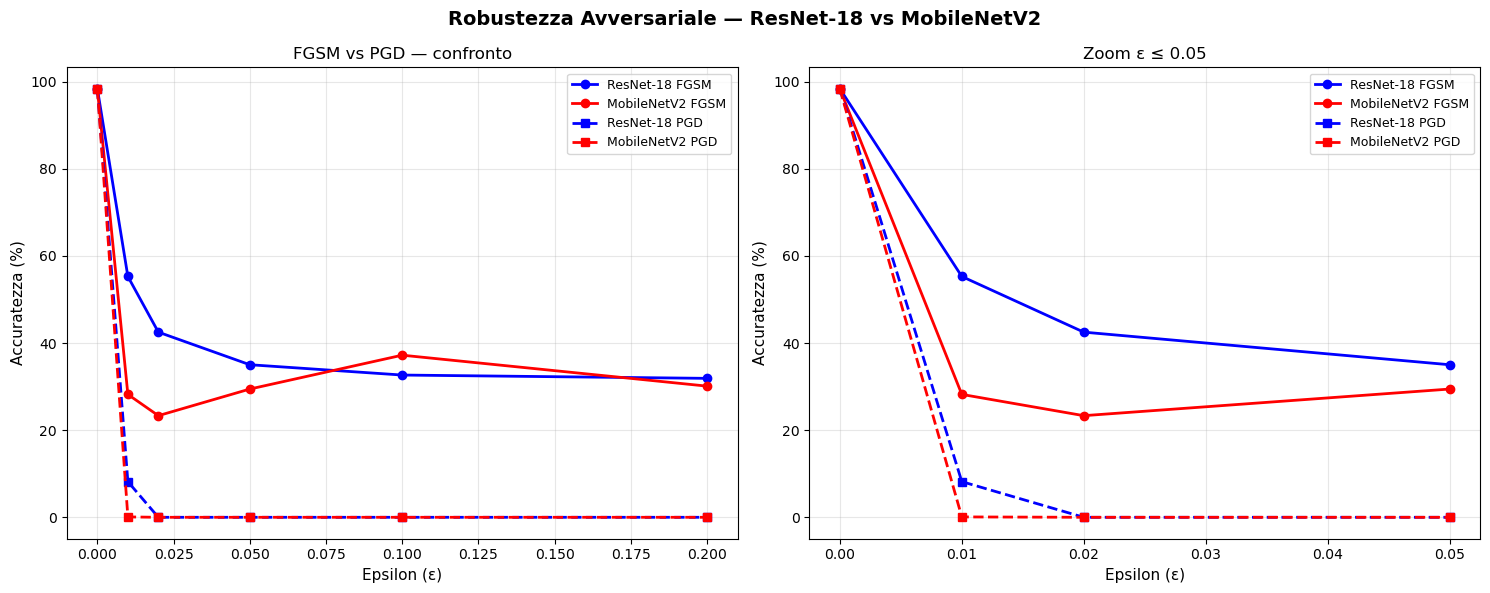


     ε |   RN-FGSM |   MN-FGSM |   Δ FGSM |   RN-PGD |   MN-PGD |   Δ PGD
────────────────────────────────────────────────────────────────────────
 0.000 |   98.36% |   98.30% |  -0.06% |  98.36% |  98.30% | -0.06%
 0.010 |   55.28% |   28.21% | -27.07% |   8.18% |   0.09% | -8.10%
 0.020 |   42.50% |   23.33% | -19.18% |   0.00% |   0.00% | +0.00%
 0.050 |   35.02% |   29.44% |  -5.58% |   0.00% |   0.00% | +0.00%
 0.100 |   32.65% |   37.21% |  +4.56% |   0.00% |   0.00% | +0.00%
 0.200 |   31.89% |   30.11% |  -1.78% |   0.00% |   0.00% | +0.00%


In [ ]:
# ── Plot robustezza avversariale ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, fgsm_rn, fgsm_mn, pgd_rn, pgd_mn, title in [
    (axes[0], results['rn_fgsm'], results['mn_fgsm'],
               results['rn_pgd'],  results['mn_pgd'],  'FGSM vs PGD — confronto'),
    (axes[1], results['rn_fgsm'], results['mn_fgsm'],
               results['rn_pgd'],  results['mn_pgd'],  'Zoom ε ≤ 0.05')
]:
    eps_plot = EPSILONS if ax == axes[0] else [e for e in EPSILONS if e <= 0.05]
    n = len(eps_plot)
    ax.plot(eps_plot, [a*100 for a in fgsm_rn[:n]], 'b-o',  lw=2, ms=6, label='ResNet-18 FGSM')
    ax.plot(eps_plot, [a*100 for a in fgsm_mn[:n]], 'r-o',  lw=2, ms=6, label='MobileNetV2 FGSM')
    ax.plot(eps_plot, [a*100 for a in pgd_rn[:n]],  'b--s', lw=2, ms=6, label='ResNet-18 PGD')
    ax.plot(eps_plot, [a*100 for a in pgd_mn[:n]],  'r--s', lw=2, ms=6, label='MobileNetV2 PGD')
    ax.set_xlabel('Epsilon (ε)', fontsize=11)
    ax.set_ylabel('Accuratezza (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Robustezza Avversariale — ResNet-18 vs MobileNetV2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_robustness.png'), dpi=150, bbox_inches='tight')
plt.show()

# Tabella
print(f'\n{"ε":>6} | {"RN-FGSM":>9} | {"MN-FGSM":>9} | {"Δ FGSM":>8} | {"RN-PGD":>8} | {"MN-PGD":>8} | {"Δ PGD":>7}')
print('─' * 72)
for i, eps in enumerate(EPSILONS):
    df = results["mn_fgsm"][i] - results["rn_fgsm"][i]
    dp = results["mn_pgd"][i]  - results["rn_pgd"][i]
    print(f'{eps:>6.3f} | {results["rn_fgsm"][i]:>8.2%} | {results["mn_fgsm"][i]:>8.2%} | '
          f'{df:>+7.2%} | {results["rn_pgd"][i]:>7.2%} | {results["mn_pgd"][i]:>7.2%} | {dp:>+6.2%}')

---
## 5. Analisi Classi β-Talassemia

Classi β-talassemia — Clean accuracy e F1

  ResNet-18  usa classi: ['Eritroblasto', 'Gran. Immaturo', 'Piastrina']
  MobileNetV2 usa classi: ['Eritroblasto', 'Gran. Immaturo', 'Piastrina']

  Classe                   RN Acc   MN Acc    RN F1   MN F1  Modello consigliato
  ───────────────────────────────────────────────────────────────────────────
  Eritroblasto            99.04% ◀β  98.71% ◀β   0.9935  0.9793  ResNet-18
  Gran. Immaturo          98.62% ◀β  97.24% ◀β   0.9589  0.9608  MobileNetV2
  Piastrina              100.00% ◀β 100.00% ◀β   1.0000  1.0000  ResNet-18


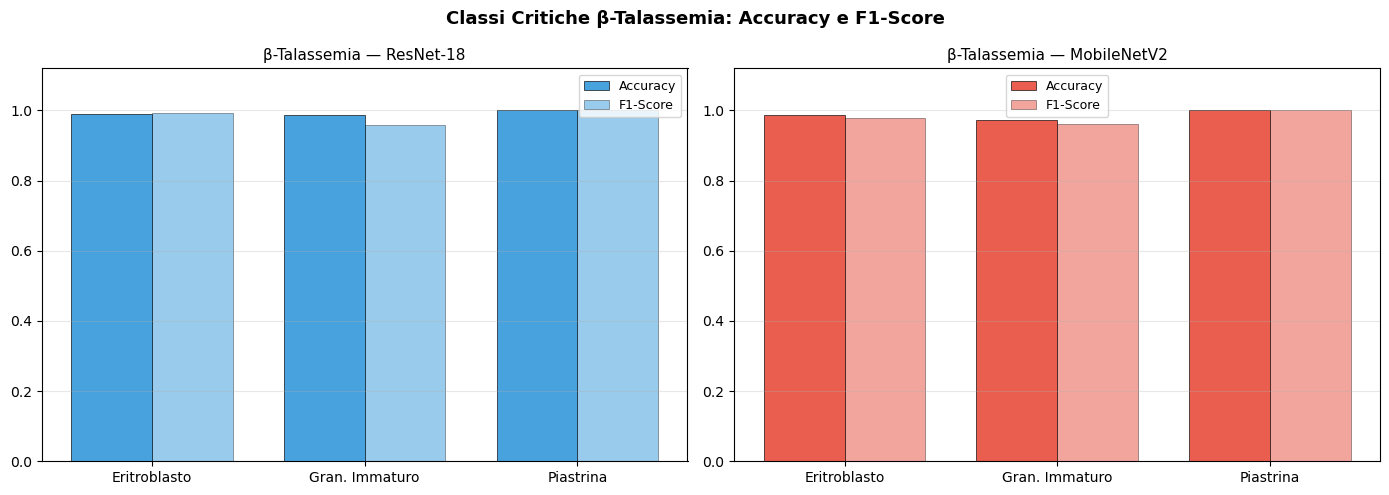

In [ ]:
# ── Accuratezza e F1 per le classi β-talassemia ──────────────────────────────
print('Classi β-talassemia — Clean accuracy e F1')
print()
print(f'  ResNet-18  usa classi: {[CLASSES[i] for i in THAL_RN]}')
print(f'  MobileNetV2 usa classi: {[CLASSES[i] for i in THAL_MN]}')
print()

all_thal = sorted(set(THAL_RN) | set(THAL_MN))
print(f'  {"Classe":<22} {"RN Acc":>8} {"MN Acc":>8}  {"RN F1":>7} {"MN F1":>7}  Modello consigliato')
print('  ' + '─' * 75)
for i in all_thal:
    cls = CLASSES[i]
    rn_ca  = accuracy_score(rn_labels[rn_labels==i], rn_preds[rn_labels==i])
    mn_ca  = accuracy_score(mn_labels[mn_labels==i], mn_preds[mn_labels==i])
    rn_f1i = f1_score(rn_labels, rn_preds, average=None)[i]
    mn_f1i = f1_score(mn_labels, mn_preds, average=None)[i]
    best   = 'ResNet-18' if rn_f1i >= mn_f1i else 'MobileNetV2'
    rn_tag = ' ◀β' if i in THAL_RN else '   '
    mn_tag = ' ◀β' if i in THAL_MN else '   '
    print(f'  {cls:<22} {rn_ca:>7.2%}{rn_tag} {mn_ca:>7.2%}{mn_tag}  {rn_f1i:>7.4f} {mn_f1i:>7.4f}  {best}')

# Plot radar β-talassemia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, labels, probs, thal, title, color in [
    (axes[0], rn_preds, rn_labels, rn_probs, THAL_RN, 'ResNet-18',   '#3498db'),
    (axes[1], mn_preds, mn_labels, mn_probs, THAL_MN, 'MobileNetV2', '#e74c3c')
]:
    thal_acc = [accuracy_score(labels[labels==i], preds[labels==i]) for i in thal]
    thal_f1  = [f1_score(labels, preds, average=None)[i] for i in thal]
    thal_n   = [CLASSES[i] for i in thal]
    x = np.arange(len(thal)); w = 0.38
    ax.bar(x - w/2, thal_acc, w, label='Accuracy', color=color, alpha=0.9, edgecolor='black', lw=0.5)
    ax.bar(x + w/2, thal_f1,  w, label='F1-Score', color=color, alpha=0.5, edgecolor='black', lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(thal_n, fontsize=10)
    ax.set_ylim(0, 1.12); ax.set_title(f'β-Talassemia — {title}', fontsize=11)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Classi Critiche β-Talassemia: Accuracy e F1-Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_thalassemia.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Grad-CAM — Spiegabilità

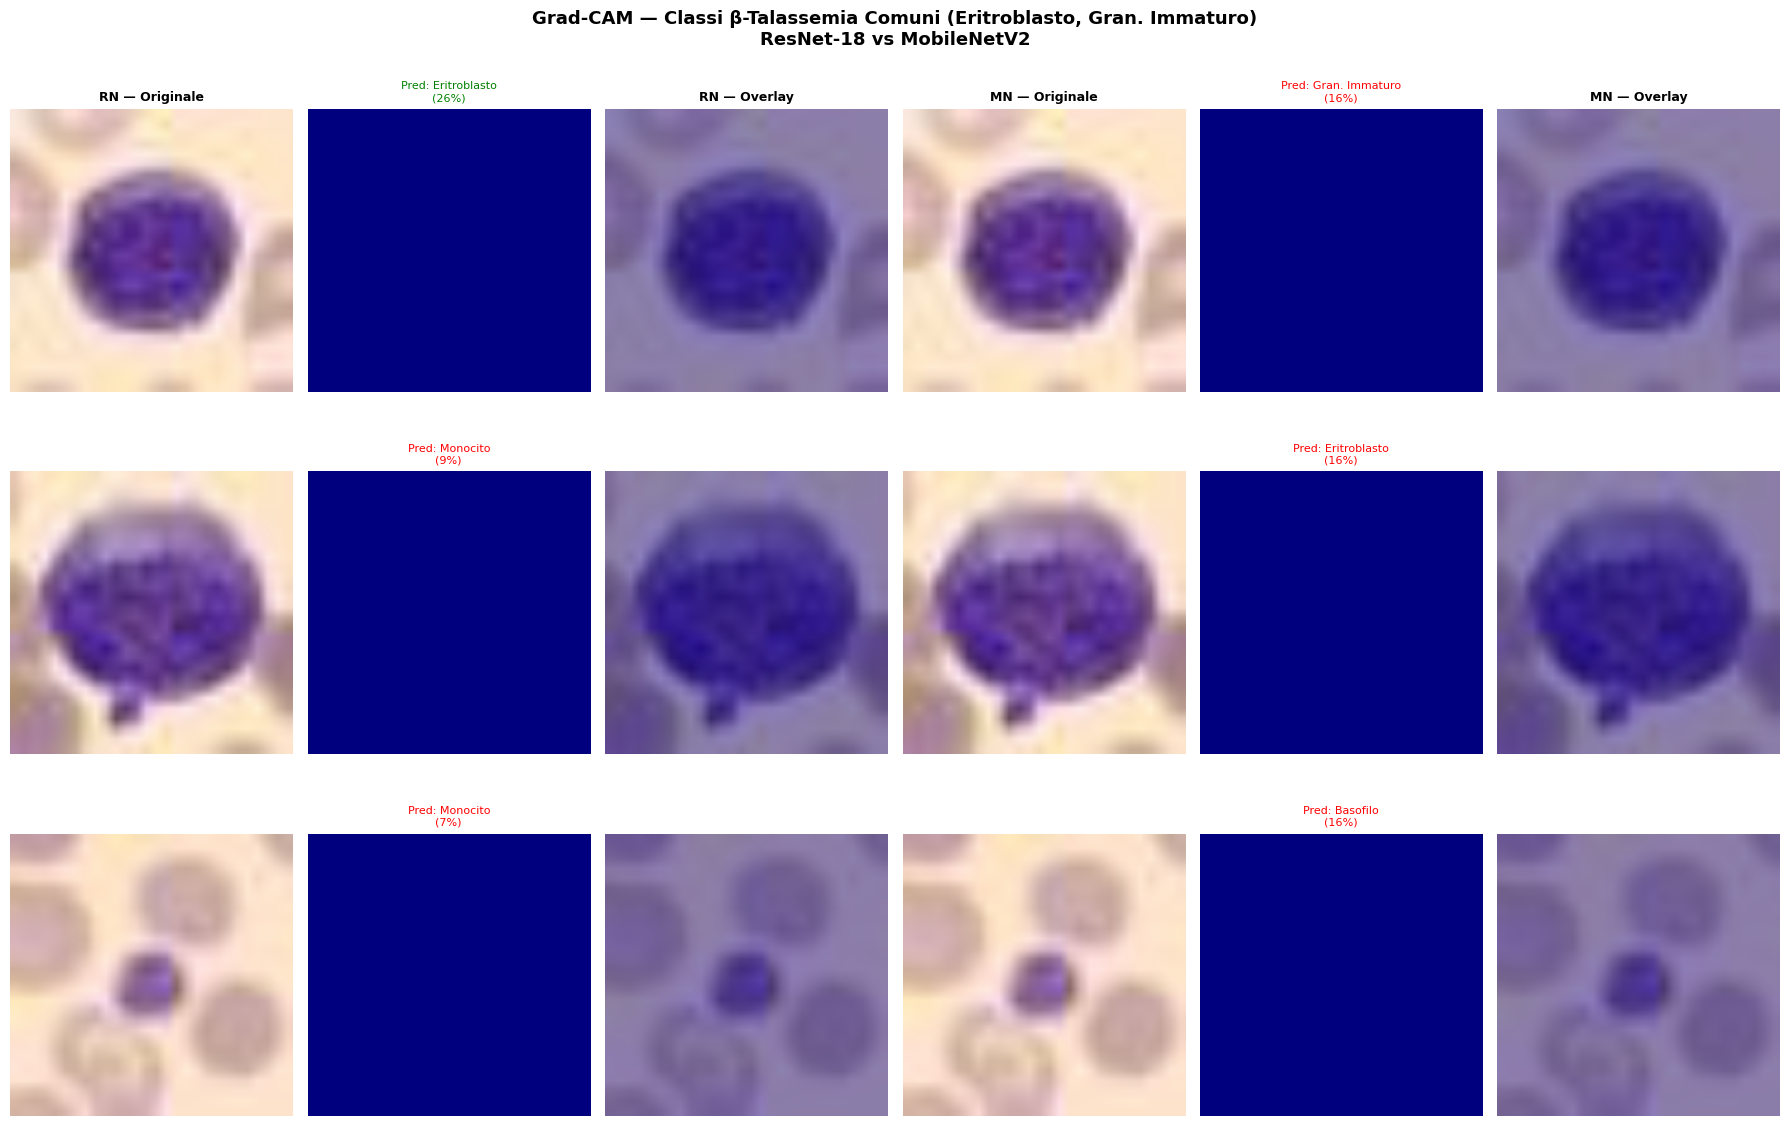

In [ ]:
# ── Grad-CAM implementation ───────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model  = model
        self.handle = target_layer.register_forward_hook(self._hook)
        self._feat  = None; self._grad = None

    def _hook(self, _, inp, out):
        self._feat = out
        out.register_hook(lambda g: setattr(self, '_grad', g))

    def generate(self, img_tensor, target_class=None):
        self.model.eval()
        inp = img_tensor.unsqueeze(0).to(device)
        out = self.model(inp)
        pred = out.argmax(1).item()
        cls  = target_class if target_class is not None else pred
        self.model.zero_grad()
        out[0, cls].backward()
        weights = self._grad[0].mean(dim=(1, 2))
        cam = (weights[:, None, None] * self._feat[0]).sum(0)
        cam = torch.clamp(cam, min=0).detach().cpu().numpy()
        cam -= cam.min(); cam /= cam.max() + 1e-8
        return cam, pred, torch.softmax(out, dim=1)[0, cls].item()

    def remove(self): self.handle.remove()

def overlay_cam(img_tensor, cam, img_size):
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = np.clip(img * std + mean, 0, 1)
    heatmap = plt.cm.jet(cam)[:, :, :3]
    heatmap  = cv2.resize(heatmap, (img_size, img_size))
    img_r    = cv2.resize(img,     (img_size, img_size))
    overlay  = np.clip(0.55 * img_r + 0.45 * heatmap, 0, 1)
    return img_r, heatmap, overlay

# Raccoglie campioni delle classi comuni β-talassemia
THAL_ALL = sorted(set(THAL_RN) & set(THAL_MN))   # [2, 3]
samples_rn, samples_mn = {}, {}

for img, label in test_dataset_rn:
    l = label.squeeze().item() if hasattr(label, 'squeeze') else int(label)
    if l in THAL_ALL and l not in samples_rn: samples_rn[l] = img
    if len(samples_rn) == len(THAL_ALL): break

for img, label in test_dataset_mn:
    l = label.squeeze().item() if hasattr(label, 'squeeze') else int(label)
    if l in THAL_ALL and l not in samples_mn: samples_mn[l] = img
    if len(samples_mn) == len(THAL_ALL): break

# Layer target (ultimo blocco convoluzionale)
gcam_rn = GradCAM(resnet,   resnet.layer4[-1])
gcam_mn = GradCAM(mobilenet, mobilenet.features[-1][0])

n_cls = len(THAL_ALL)
fig, axes = plt.subplots(n_cls, 6, figsize=(18, 4 * n_cls))
if n_cls == 1: axes = axes[np.newaxis, :]

col_titles = ['RN — Originale', 'RN — CAM', 'RN — Overlay',
              'MN — Originale', 'MN — CAM', 'MN — Overlay']
for col_i, ttl in enumerate(col_titles):
    axes[0, col_i].set_title(ttl, fontsize=9, fontweight='bold')

for row_i, cls_idx in enumerate(THAL_ALL):
    cls_name = CLASSES[cls_idx]
    axes[row_i, 0].set_ylabel(cls_name, fontsize=11, fontweight='bold')

    cam_rn, pred_rn, conf_rn = gcam_rn.generate(samples_rn[cls_idx], cls_idx)
    cam_mn, pred_mn, conf_mn = gcam_mn.generate(samples_mn[cls_idx], cls_idx)

    img_rn, hm_rn, ov_rn = overlay_cam(samples_rn[cls_idx], cam_rn, IMG_RN)
    img_mn, hm_mn, ov_mn = overlay_cam(samples_mn[cls_idx], cam_mn, IMG_MN)

    for col_i, (img_show, is_jet) in enumerate([
        (img_rn, False), (hm_rn, True), (ov_rn, False),
        (img_mn, False), (hm_mn, True), (ov_mn, False)
    ]):
        ax = axes[row_i, col_i]
        ax.imshow(img_show, cmap='jet' if is_jet else None)
        ax.axis('off')
        if col_i == 1:
            color = 'green' if pred_rn == cls_idx else 'red'
            ax.set_title(f'Pred: {CLASSES[pred_rn]}\n({conf_rn:.0%})', fontsize=8, color=color)
        elif col_i == 4:
            color = 'green' if pred_mn == cls_idx else 'red'
            ax.set_title(f'Pred: {CLASSES[pred_mn]}\n({conf_mn:.0%})', fontsize=8, color=color)

gcam_rn.remove(); gcam_mn.remove()
plt.suptitle('Grad-CAM — Classi β-Talassemia Comuni (Eritroblasto, Gran. Immaturo)\nResNet-18 vs MobileNetV2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'comparison_gradcam.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Tabella Riepilogativa

In [ ]:
# ── Tabella riepilogativa finale ─────────────────────────────────────────────
print('=' * 65)
print('   CONFRONTO ResNet-18 vs MobileNetV2 — BloodMNIST')
print('=' * 65)

metrics = [
    ('Parametri totali',       f'{rn_total:,}',                    f'{mn_total:,}'),
    ('Dimensione pesi',        f'{rn_size_mb:.1f} MB',             f'{mn_size_mb:.1f} MB'),
    ('Input size',             f'{IMG_RN}×{IMG_RN}',               f'{IMG_MN}×{IMG_MN}'),
    ('Velocità inferenza',     f'{rn_speed:.1f} ms/batch',         f'{mn_speed:.1f} ms/batch'),
    ('─' * 25,                 '─' * 14,                           '─' * 14),
    ('Test accuracy (clean)',  f'{rn_acc:.4%}',                    f'{mn_acc:.4%}'),
    ('Macro F1 (clean)',       f'{rn_macro:.4f}',                  f'{mn_macro:.4f}'),
    ('─' * 25,                 '─' * 14,                           '─' * 14),
    ('FGSM acc @ ε=0.01',     f'{results["rn_fgsm"][1]:.2%}',   f'{results["mn_fgsm"][1]:.2%}'),
    ('FGSM acc @ ε=0.05',     f'{results["rn_fgsm"][3]:.2%}',   f'{results["mn_fgsm"][3]:.2%}'),
    ('PGD acc  @ ε=0.01',     f'{results["rn_pgd"][1]:.2%}',    f'{results["mn_pgd"][1]:.2%}'),
    ('PGD acc  @ ε=0.05',     f'{results["rn_pgd"][3]:.2%}',    f'{results["mn_pgd"][3]:.2%}'),
    ('─' * 25,                 '─' * 14,                           '─' * 14),
    ('Classi β-talassemia',   str([CLASSES[i] for i in THAL_RN]), str([CLASSES[i] for i in THAL_MN])),
]

print(f'  {"Metrica":<26} {"ResNet-18":>14} {"MobileNetV2":>14}')
print('  ' + '─' * 57)
for m, rn_v, mn_v in metrics:
    print(f'  {m:<26} {rn_v:>14} {mn_v:>14}')

print('=' * 65)
print()
print('CONCLUSIONI:')
winner_acc  = 'ResNet-18' if rn_acc  > mn_acc  else 'MobileNetV2'
winner_f1   = 'ResNet-18' if rn_macro > mn_macro else 'MobileNetV2'
winner_rob  = 'ResNet-18' if results["rn_pgd"][3] > results["mn_pgd"][3] else 'MobileNetV2'
winner_size = 'MobileNetV2' if mn_size_mb < rn_size_mb else 'ResNet-18'
winner_spd  = 'MobileNetV2' if mn_speed < rn_speed else 'ResNet-18'

print(f'  Accuratezza clean:    {winner_acc} superiore ({abs(rn_acc-mn_acc):.2%} di gap)')
print(f'  Macro F1:             {winner_f1} superiore')
print(f'  Robustezza (PGD):     {winner_rob} più robusto a ε=0.05')
print(f'  Efficienza parametri: {winner_size} più compatto ({min(rn_size_mb,mn_size_mb):.1f} MB vs {max(rn_size_mb,mn_size_mb):.1f} MB)')
print(f'  Velocità inferenza:   {winner_spd} più veloce')

   CONFRONTO ResNet-18 vs MobileNetV2 — BloodMNIST
  Metrica                         ResNet-18    MobileNetV2
  ─────────────────────────────────────────────────────────
  Parametri totali               11,180,616      2,553,864
  Dimensione pesi                   44.7 MB        10.2 MB
  Input size                        224×224        224×224
  Velocità inferenza         766.9 ms/batch 743.4 ms/batch
  ─────────────────────────  ────────────── ──────────────
  Test accuracy (clean)            98.3631%       98.3046%
  Macro F1 (clean)                   0.9848         0.9836
  ─────────────────────────  ────────────── ──────────────
  FGSM acc @ ε=0.01                  55.28%         28.21%
  FGSM acc @ ε=0.05                  35.02%         29.44%
  PGD acc  @ ε=0.01                   8.18%          0.09%
  PGD acc  @ ε=0.05                   0.00%          0.00%
  ─────────────────────────  ────────────── ──────────────
  Classi β-talassemia        ['Eritroblasto', 'Gran. Immaturo',